In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Cleaning data

In [74]:
cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err.  R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']

In [75]:
df = pd.read_csv('1803+784_dem.txt', sep='\s+', skiprows=4, names=cols, header=None, index_col=False)
df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
0,45754.258,-1.909625186745,-1.887001,1.2912,0.7417,-0.084,40.0
1,45759.251,-1.554359283060,-2.305602,1.2032,1.1362,0.028,19.0
2,45764.244,0.051039534973,1.460398,0.7069,0.6182,0.325,21.0
3,45769.259,-5.738531827789,0.891000,2.5316,1.1073,-0.363,25.0
4,45864.264,-2.972004238790,0.696600,0.6484,0.6307,0.547,27.0
...,...,...,...,...,...,...,...
2724,60181.271,-0.607553070938,-0.275702,0.2258,0.2346,0.037,65.0
2725,60188.269,0.015383760990,0.475898,0.1854,0.1910,0.278,107.0
2726,60195.271,0.066453528946,0.082897,0.1307,0.1282,0.102,201.0
2727,60202.270,-1.387176858925,-4.237200,0.1272,0.1330,0.139,98.0


In [76]:
df.dtypes

MJD                  object
R.A. (mas)           object
Dec. (mas)          float64
Err.  R.A. (mas)    float64
Err. Dec. (mas)     float64
Corr.               float64
Del.                float64
dtype: object

In [77]:
# Convert MJD to float64
df['MJD'] = pd.to_numeric(df['MJD'])

ValueError: Unable to parse string "58316.206************************************" at position 2414

In [78]:
# Examine problematic row
print(df.loc[[2414]])

                                                MJD R.A. (mas)  Dec. (mas)  \
2414  58316.206************************************     0.0873      0.1039   

      Err.  R.A. (mas)  Err. Dec. (mas)  Corr.  Del.  
2414             0.071            202.0    NaN   NaN  


In [79]:
# Drop problematic row
df = df.drop(df.index[2414])

In [80]:
df['MJD'] = pd.to_numeric(df['MJD'])

In [84]:
# Change MJD to BY 
# BY=2000-(51544.333981-MJD)/365.242198781
df['BY'] = 2000-(51544.333981-df['MJD'])/365.242198781

In [85]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,BY
0,45754.258,-1.909625186745,-1.887001,1.2912,0.7417,-0.084,40.0,1984.147297
1,45759.251,-1.554359283060,-2.305602,1.2032,1.1362,0.028,19.0,1984.160968
2,45764.244,0.051039534973,1.460398,0.7069,0.6182,0.325,21.0,1984.174638
3,45769.259,-5.738531827789,0.891000,2.5316,1.1073,-0.363,25.0,1984.188369
4,45864.264,-2.972004238790,0.696600,0.6484,0.6307,0.547,27.0,1984.448484


# Allan Deviation

In [112]:
def allanoadev_opt(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        kernels = np.ones(m[k])/m[k]
        ybar = np.convolve(y,kernels,'valid')

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd

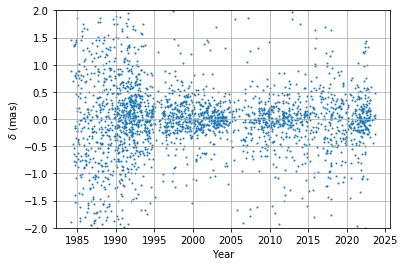

In [101]:
plt.scatter(df['BY'], df['Dec. (mas)'],s=1)
#plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ecolor='grey')
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [115]:
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

In [119]:
%%time
tau_dec, allanstd_dec = allanoadev_opt(df['Dec. (mas)'],t,1)

CPU times: user 3min 51s, sys: 270 ms, total: 3min 52s
Wall time: 3min 51s


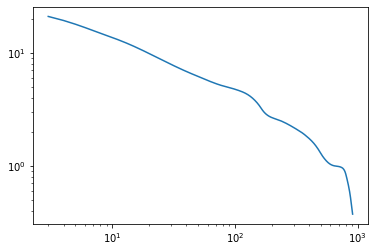

In [120]:
plt.loglog(tau_dec,allanstd_dec)